# House Price Prediction using Linear Regression
## Define Problem
Dự đoán giá nhà là một bài toán quan trọng trong thực tế vì nó giúp chúng ta định giá được giá trị căn nhà dựa trên các đặc điểm như diện tích, chất lượng, sống phòng và vị trí.

Mục tiêu của dự án này là xây dựng một mô hình **Linear Regression** để dự đoán nhà dựa trên các đặc trưng có trong bộ dữ liệu.

Bộ dữ liệu bao gồm nhiều đặc trưng của căn nhà như chất lượng tổng thể, diện tích sinh hoạt, diện tích tầng hầm, năm xây dựng, số chỗ để xe và nhiều biến khác. Biến mục tiêu là `SalePrice`, đại diện cho giá bán cuối cùng của mỗi căn nhà.  

Đây là **Supervised Learning Regression** vì dữ liệu có cả đặc trưng đầu vào và giá trị mục tiêu đã biết.Trong dự án này, Linear Regression được sử dụng làm mô hình chính vì nó đơn giản, dễ hiểu và hữu ích để phân tích mối quan hệ giữa các đặc trưng của căn nhà và giá nhà.

## E2E Processing Flow
Dưới đây là luồng xử lý tổng thể (End-to-End Pipeline) bám sát 6 bước:
1. **Data Collection & Understanding**: Đọc dữ liệu thô từ `train.csv`, hiểu các cột và xác định biến mục tiêu `SalePrice`.
2. **Data Preprocessing**: Làm sạch dữ liệu (missing values, duplicates, outliers), EDA và Feature Engineering (One-Hot Encoding).
3. **Data Splitting**: Chia tập huấn luyện (training set) và kiểm tra (test set) để đánh giá khách quan trên dữ liệu mới.
4. **Model Selection & Training**: Lựa chọn Linear Regression làm baseline model và huấn luyện.
5. **Evaluation & Tuning**: Đánh giá hiệu suất bằng MAE, MSE, RMSE, R² và trực quan hóa Actual vs Predicted, Residual Plot.
6. **Deployment & Monitoring**: Dự đoán mẫu thử, so sánh thực tế và định hướng theo dõi, cải thiện mô hình.

![E2E Processing Flow](../image/flow_linear_learning.png)

# Datasets: https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data?select=train.csv

### Dataset Overview

Bộ dữ liệu được sử dụng là **House Prices - Advanced Regression Techniques** từ Kaggle. Dataset này mô tả thông tin nhà ở tại **Ames, Iowa**, với nhiều đặc trưng như diện tích, chất lượng nhà, năm xây dựng, gara, tầng hầm, vị trí và điều kiện bán nhà.

Mục tiêu của bài toán là dự đoán **giá bán nhà**. Biến mục tiêu là `SalePrice`.

Đây là bài toán **Supervised Learning - Regression** vì dữ liệu đã có giá nhà thực tế và mô hình cần dự đoán một giá trị số liên tục.

Trong project này:

- **Input features:** các đặc trưng mô tả căn nhà.
- **Output/Target:** `SalePrice`.
- **Model sử dụng:** Linear Regression.
- **File dữ liệu chính:** `train.csv`.

### Feature Description

Các feature trong dataset có thể chia thành các nhóm chính:

| Nhóm feature | Một số cột tiêu biểu | Mô tả |
|---|---|---|
| Thông tin lô đất | `LotArea`, `LotFrontage`, `LotShape` | Mô tả diện tích, mặt tiền và hình dạng lô đất. |
| Vị trí | `Neighborhood`, `MSZoning` | Mô tả khu vực và phân vùng quy hoạch của căn nhà. |
| Chất lượng nhà | `OverallQual`, `OverallCond` | Thể hiện chất lượng và tình trạng tổng thể của căn nhà. |
| Thời gian xây dựng | `YearBuilt`, `YearRemodAdd` | Cho biết năm xây dựng và năm cải tạo gần nhất. |
| Diện tích nhà | `GrLivArea`, `1stFlrSF`, `2ndFlrSF`, `TotalBsmtSF` | Mô tả diện tích sinh hoạt, diện tích tầng 1, tầng 2 và tầng hầm. |
| Phòng và tiện ích | `BedroomAbvGr`, `FullBath`, `HalfBath`, `KitchenQual` | Mô tả số phòng ngủ, phòng tắm và chất lượng nhà bếp. |
| Gara | `GarageCars`, `GarageArea`, `GarageType` | Mô tả sức chứa, diện tích và loại gara. |
| Ngoại thất và tiện ích khác | `Exterior1st`, `RoofStyle`, `WoodDeckSF`, `PoolArea`, `Fence` | Mô tả ngoại thất và các tiện ích bổ sung. |
| Thông tin bán nhà | `MoSold`, `YrSold`, `SaleType`, `SaleCondition` | Mô tả thời điểm và điều kiện bán nhà. |

### Target Variable

`SalePrice` là biến mục tiêu của bài toán.

Nó thể hiện **giá bán cuối cùng của căn nhà** theo đơn vị USD.  
Mô hình Linear Regression sẽ học mối quan hệ giữa các đặc trưng đầu vào và `SalePrice` để dự đoán giá nhà cho dữ liệu mới.

## 1. Data Collection & Understanding

### Import Libraries
Import các thư viện cần thiết cho việc thao tác dữ liệu (`pandas`, `numpy`), trực quan hóa (`matplotlib`, `seaborn`) và xây dựng mô hình (`scikit-learn`).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

### Load Dataset
Đọc dữ liệu từ file `train.csv`. Vì mục tiêu là học và tự validate, chúng ta sẽ chỉ dùng tập `train.csv` và sau đó tự chia tập train/test.

In [2]:
df = pd.read_csv('../data/train.csv')
print(f"Dataset shape: {df.shape}")

Dataset shape: (1460, 81)


### Data Overview
Xem xét cấu trúc của tập dữ liệu: các cột, kiểu dữ liệu, và một vài thống kê mô tả cơ bản.

In [3]:
display(df.head())
df.info()
display(df.describe())

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


## 2. Data Preprocessing
### Data Cleaning
Làm sạch dữ liệu bao gồm:
1. **Loại bỏ dòng trùng lặp**.
2. **Phân tích dữ liệu thiếu (Missing Value Analysis)**: Lập bảng thống kê các cột bị thiếu dữ liệu.
3. **Phân tích ngoại lệ (Outlier Analysis)**: Loại bỏ các điểm dị biệt quá mức (ví dụ: diện tích cực lớn nhưng giá rất rẻ).

### Before Data Cleaning
Bước kiểm tra dữ liệu trước khi làm sạch (Before cleaning) được thực hiện để đánh giá chất lượng dữ liệu gốc. Việc so sánh trạng thái trước và sau giúp chứng minh các thao tác Data Cleaning là cần thiết và có tác dụng.

Shape trước khi clean: (1460, 81)
Số duplicate rows trước khi clean: 0

--- Bảng Missing Values trước khi clean ---


,Missing Count,Missing Percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027


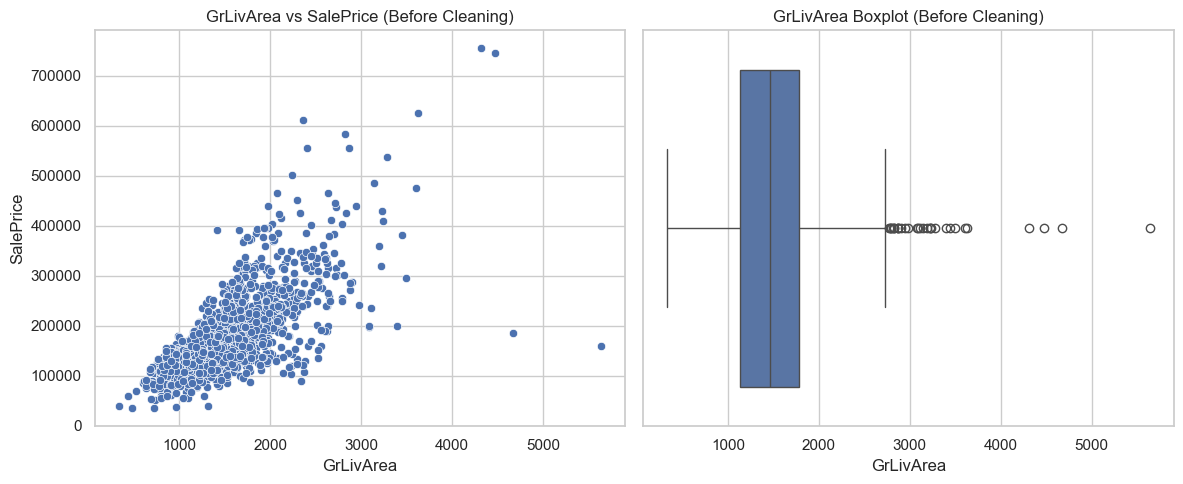

In [ ]:
rows_before_cleaning = df.shape[0]
duplicate_rows_before = df.duplicated().sum()

print(f"Shape trước khi clean: {df.shape}")
print(f"Số duplicate rows trước khi clean: {duplicate_rows_before}")

missing_before = df.isnull().sum()
missing_before_df = pd.DataFrame({'Missing Count': missing_before, 'Missing Percentage': (missing_before / len(df)) * 100})
missing_before_df = missing_before_df[missing_before_df['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)
print("\n--- Bảng Missing Values trước khi clean ---")
display(missing_before_df.head())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(data=df, x='GrLivArea', y='SalePrice', ax=axes[0])
axes[0].set_title('GrLivArea vs SalePrice (Before Cleaning)')

sns.boxplot(data=df, x='GrLivArea', ax=axes[1])
axes[1].set_title('GrLivArea Boxplot (Before Cleaning)')
plt.tight_layout()
plt.show()

### Data Cleaning Process
*Lưu ý: Không fill missing values trực tiếp trên toàn bộ dataset ở bước này để tránh data leakage. Missing values sẽ được xử lý bằng Pipeline ở giai đoạn sau.*

In [ ]:
initial_rows = df.shape[0]
df = df.drop_duplicates()
print(f"Dropped {initial_rows - df.shape[0]} duplicate rows.\n")

missing_counts = df.isnull().sum()
missing_percentage = (missing_counts / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_counts, 'Missing Percentage': missing_percentage})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

print("--- Missing Values Table ---")
display(missing_df)

outliers = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)].index
df = df.drop(outliers)
print(f"\nDropped {len(outliers)} outlier rows.")

Dropped 0 duplicate rows.

--- Missing Values Table ---


,Missing Count,Missing Percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945



Dropped 2 outlier rows.


### After Data Cleaning
Bước này nhằm xác nhận dữ liệu đã được làm sạch đúng theo logic đã định. Việc so sánh trước/sau giúp đảm bảo quá trình Data Cleaning đạt hiệu quả.

Shape sau khi clean: (1458, 81)
Số duplicate rows sau khi clean: 0


,Metric,Value
0,Rows before cleaning,1460
1,Rows after cleaning,1458
2,Duplicate rows removed,0
3,Outlier rows removed,2



--- Bảng Missing Values sau khi clean (sẽ xử lý trong Pipeline) ---


,Missing Count,Missing Percentage
PoolQC,1452,99.588477
MiscFeature,1404,96.296296
Alley,1367,93.758573
Fence,1177,80.727023
MasVnrType,872,59.807956


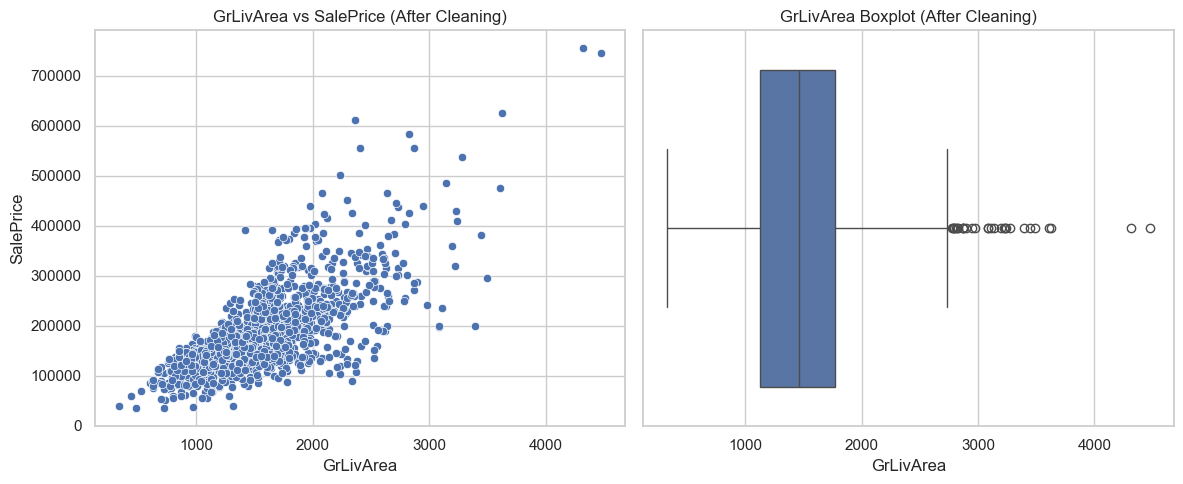

In [ ]:
print(f"Shape sau khi clean: {df.shape}")
print(f"Số duplicate rows sau khi clean: {df.duplicated().sum()}")

outliers_count = rows_before_cleaning - duplicate_rows_before - df.shape[0]

comparison_data = {
    'Metric': ['Rows before cleaning', 'Rows after cleaning', 'Duplicate rows removed', 'Outlier rows removed'],
    'Value': [rows_before_cleaning, df.shape[0], duplicate_rows_before, outliers_count]
}
display(pd.DataFrame(comparison_data))

missing_after = df.isnull().sum()
missing_after_df = pd.DataFrame({'Missing Count': missing_after, 'Missing Percentage': (missing_after / len(df)) * 100})
missing_after_df = missing_after_df[missing_after_df['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)
if len(missing_after_df) > 0:
    print("\n--- Bảng Missing Values sau khi clean (sẽ xử lý trong Pipeline) ---")
    display(missing_after_df.head())
else:
    print("\nKhông còn missing values.")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(data=df, x='GrLivArea', y='SalePrice', ax=axes[0])
axes[0].set_title('GrLivArea vs SalePrice (After Cleaning)')

sns.boxplot(data=df, x='GrLivArea', ax=axes[1])
axes[1].set_title('GrLivArea Boxplot (After Cleaning)')
plt.tight_layout()
plt.show()

### Exploratory Data Analysis (EDA)
Phân tích khám phá dữ liệu:
- Xem phân phối của `SalePrice`.
- Liệt kê top 10 đặc trưng dạng số tương quan mạnh nhất với `SalePrice`.
- Trực quan hóa (Scatter plot và Boxplot) để thấy rõ mối quan hệ.

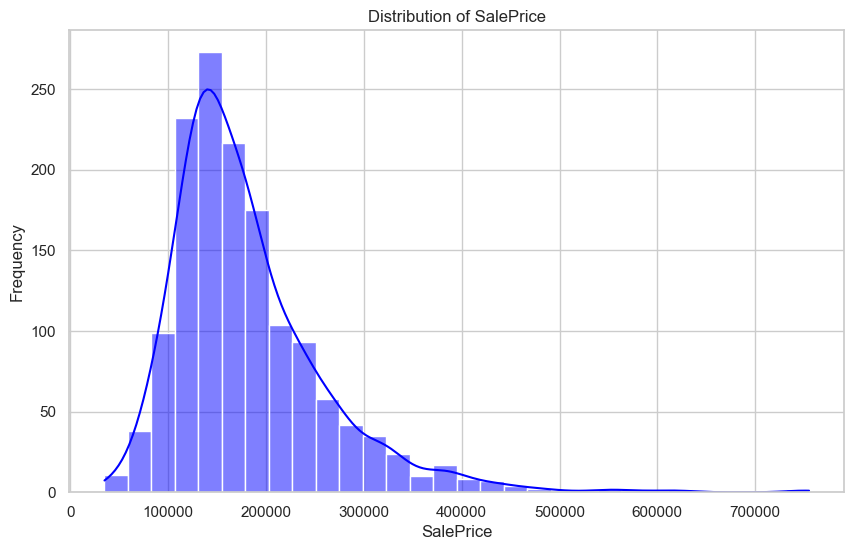

In [7]:
# Distribution of SalePrice
plt.figure(figsize=(10, 6))
sns.histplot(df['SalePrice'], kde=True, color='blue', bins=30)
plt.title('Distribution of SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.show()


--- Top 10 numerical features correlated with SalePrice ---


,SalePrice
SalePrice,1.000000
OverallQual,0.795774
GrLivArea,0.734968
TotalBsmtSF,0.651153
GarageCars,0.641047
1stFlrSF,0.631530
GarageArea,0.629217
FullBath,0.562165
TotRmsAbvGrd,0.537769
YearBuilt,0.523608


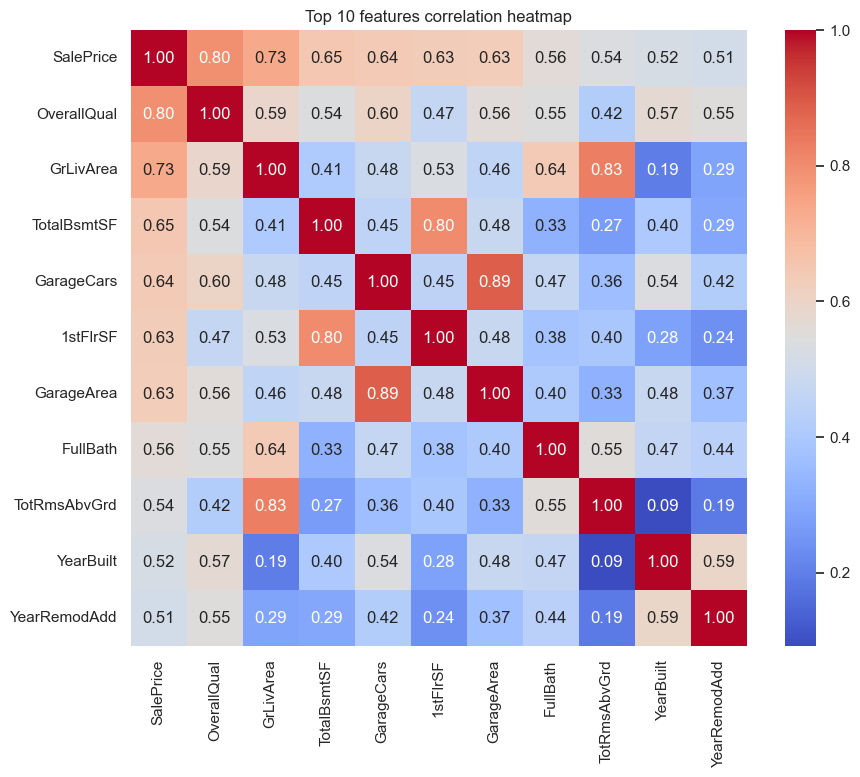

In [8]:
numeric_cols = df.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()
top_corr_cols = corr_matrix.nlargest(11, 'SalePrice')['SalePrice']
print("--- Top 10 numerical features correlated with SalePrice ---")
display(top_corr_cols.to_frame())

top_corr_matrix = df[top_corr_cols.index].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(top_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Top 10 features correlation heatmap')
plt.show()

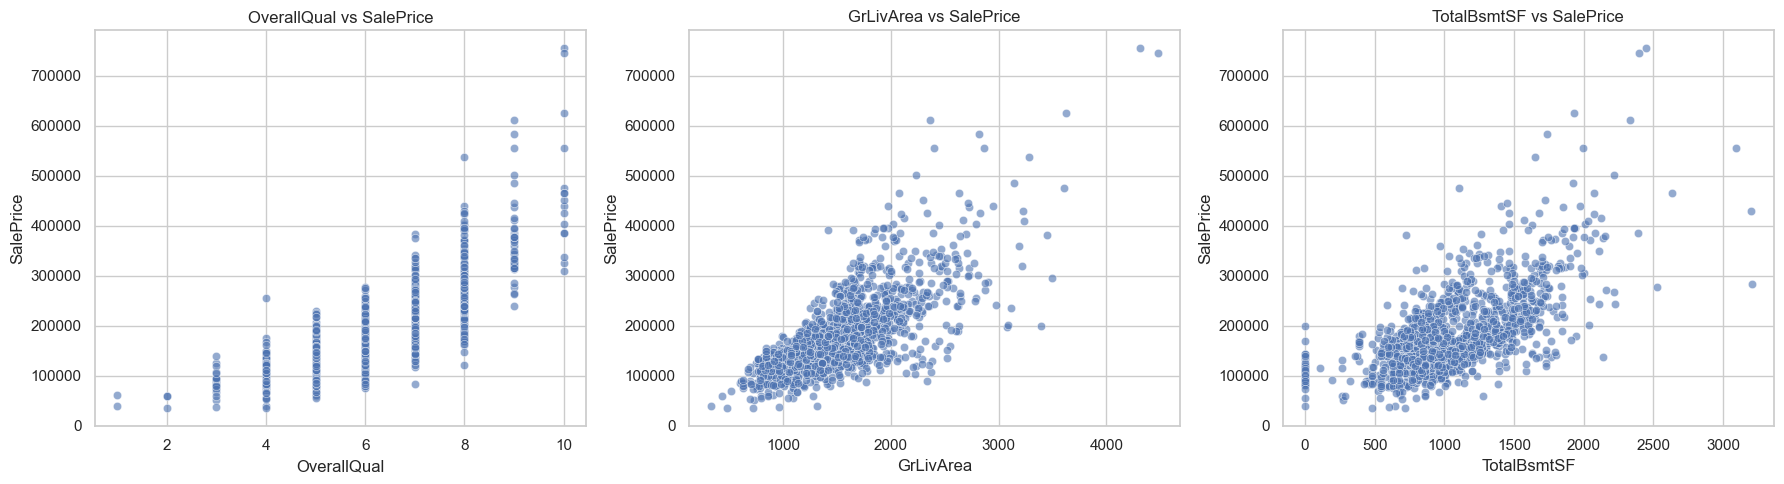

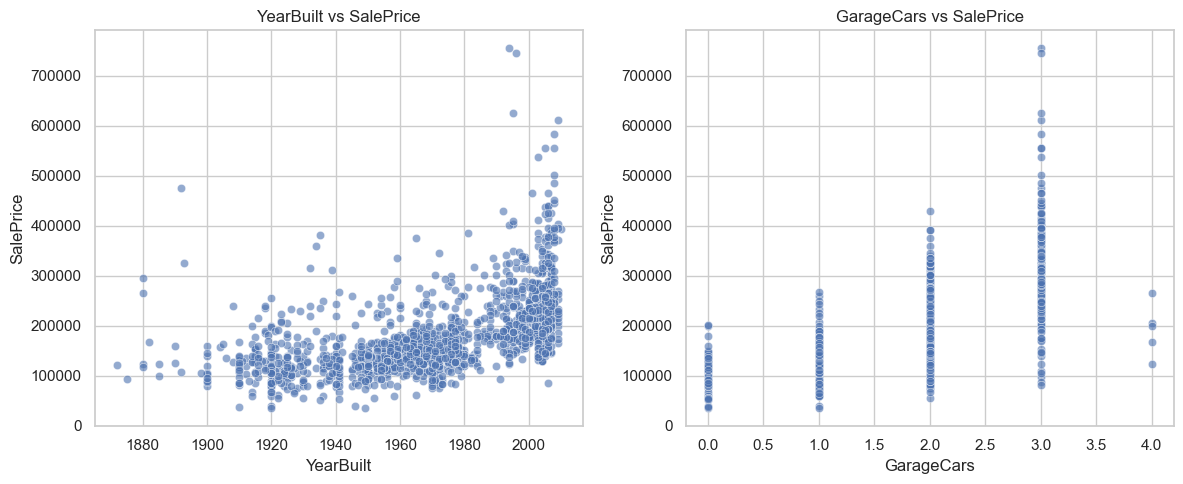

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(ax=axes[0], x=df['OverallQual'], y=df['SalePrice'], alpha=0.6)
axes[0].set_title('OverallQual vs SalePrice')

sns.scatterplot(ax=axes[1], x=df['GrLivArea'], y=df['SalePrice'], alpha=0.6)
axes[1].set_title('GrLivArea vs SalePrice')

sns.scatterplot(ax=axes[2], x=df['TotalBsmtSF'], y=df['SalePrice'], alpha=0.6)
axes[2].set_title('TotalBsmtSF vs SalePrice')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(ax=axes[0], x=df['YearBuilt'], y=df['SalePrice'], alpha=0.6)
axes[0].set_title('YearBuilt vs SalePrice')

sns.scatterplot(ax=axes[1], x=df['GarageCars'], y=df['SalePrice'], alpha=0.6)
axes[1].set_title('GarageCars vs SalePrice')
plt.tight_layout()
plt.show()

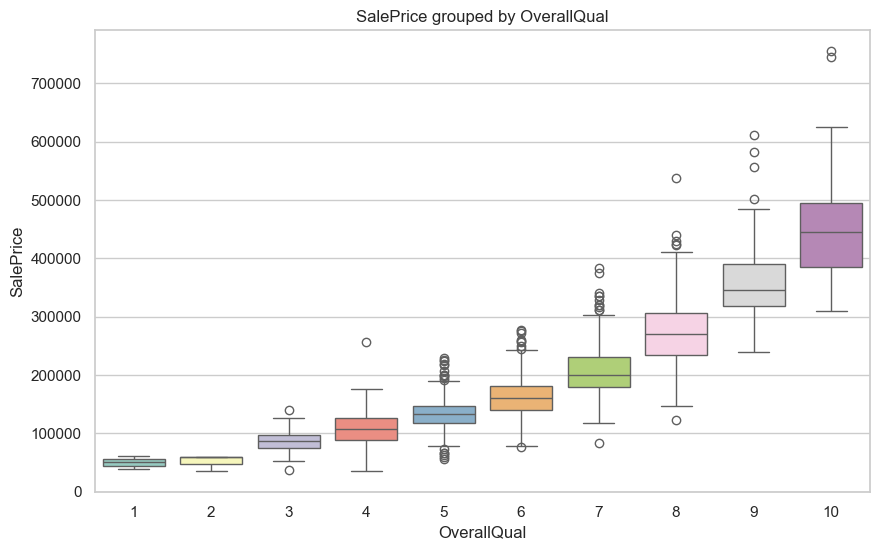

In [10]:
# Boxplot SalePrice by OverallQual
plt.figure(figsize=(10, 6))
sns.boxplot(x='OverallQual', y='SalePrice', data=df, palette='Set3')
plt.title('SalePrice grouped by OverallQual')
plt.show()

### Feature Preprocessing

Các bước:
1. Tách `X` (features) và `y` (target).
2. Bỏ cột `Id` và các cột thiếu quá nhiều dữ liệu (>80%).

In [11]:
# 1. Separate features (X) and target (y)
y = df['SalePrice']
X = df.drop(columns=['SalePrice'])

# 2. Drop ID and columns with > 80% missing values
if 'Id' in X.columns:
    X = X.drop(columns=['Id'])

missing_ratio = X.isnull().sum() / len(X)
cols_to_drop = missing_ratio[missing_ratio > 0.8].index
X = X.drop(columns=cols_to_drop)
print(f"Dropped columns with too many nulls: {list(cols_to_drop)}")
print(f"Shape of X: {X.shape}")

Dropped columns with too many nulls: ['Alley', 'PoolQC', 'Fence', 'MiscFeature']
Shape of X: (1458, 75)


## 3. Data Splitting
Chia `X` và `y` thành tập Huấn luyện (80%) và tập Kiểm tra (20%).
Sử dụng `train_test_split` với `test_size=0.2` và `random_state=42`.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (1166, 75), y_train shape: (1166,)
X_test shape: (292, 75), y_test shape: (292,)


## 4. Model Selection & Training
Xây dựng một **Pipeline** bao gồm các bước xử lý dữ liệu và huấn luyện mô hình.
1. **Xác định loại biến**: Chia các cột thành số (numerical) và chữ (categorical) dựa trên `X_train`.
2. **Tạo Preprocessing Pipeline**:
   - *Numerical*: Lấp đầy giá trị thiếu bằng trung vị (`SimpleImputer(strategy='median')`), sau đó chuẩn hóa (`StandardScaler()`).
   - *Categorical*: Lấp đầy giá trị thiếu bằng chuỗi 'None' (`SimpleImputer(strategy='constant')`), sau đó mã hóa (`OneHotEncoder(handle_unknown='ignore')`).
3. **Full Pipeline**: Kết hợp preprocessing bằng `ColumnTransformer` và mô hình `LinearRegression`.

In [14]:
# 1. Identify numerical and categorical columns from X_train
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns

# 2. Create preprocessing pipelines for both types of features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 3. Combine transformers into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 4. Create the full pipeline with preprocessing and the linear regression model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# 5. Train the model using the pipeline
model.fit(X_train, y_train)
print("Pipeline with Linear Regression Model successfully trained!")

Pipeline with Linear Regression Model successfully trained!
